# Employee Attrition Prediction with an Artificial Neural Network

## Business case

Employee attrition can create recruitment costs, lost productivity, disruption to teams, and the loss of organisational knowledge. The purpose of this analysis is to explore whether employee data can be used to identify patterns associated with attrition and to build an early-warning classification model that may support retention activity.

The supplied dataset contains 10,000 employee records and 29 columns, including the binary target `Left` (`1` = employee left, `0` = employee stayed). The available variables cover employee characteristics, tenure, salary, work-life balance, satisfaction, performance, development indicators and employment-related categories.

The analysis has two objectives:

1. **Explore the factors associated with attrition** through descriptive analysis and visualisation.
2. **Build and evaluate an Artificial Neural Network (ANN)** that classifies employees as likely to stay or leave.

The exploratory results should be interpreted as associations rather than evidence that any individual factor *causes* an employee to leave. Likewise, model predictions are intended as decision support rather than a basis for automated employment decisions.


### Importing the libraries

The analysis uses `pandas` and `NumPy` for data handling, `Matplotlib` and `Seaborn` for visualisation, and TensorFlow/Keras to build the neural network.


In [ ]:
pip install tensorflow

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
plt.style.use("default")
warnings.filterwarnings('ignore')
import tensorflow as tf

In [ ]:
tf.__version__

'2.11.0'

## Part 1 — Data preprocessing and exploratory analysis

The first stage checks the structure and quality of the data, explores the distribution of the target and key variables, and prepares the selected features for modelling.


### Importing and inspecting the dataset

The dataset contains 10,000 employee records. Initial inspection is used to confirm the available fields, data types and missing values before any modelling decisions are made.

`Leaving_Date` is missing for 8,133 records; this count matches the number of employees whose target indicates that they stayed. Because this field would only be known after an employee leaves, it is removed before modelling to avoid target leakage.


In [ ]:
dataset = pd.read_csv('data/employee_attrition_data.csv')

In [ ]:
dataset.head()

,RowNumber,EmpID,Surname,Position,Birthday_Date,Start_Date,Leaving_Date,Grade_Group,Contract_Type,Contract_Hours,...,Environment_Satisfaction,Satisfaction_Level,Last_Year_Evaluation,Time_Since_Promotion,Ease_of_External_Resourcing,Possible_Future_Training,In_Development_Role,Want_Change_Career,Salary,Left
0,1,15634602,Hargrave,Accountant,19/07/1957,01/01/2011,08/05/2020,White Collar,Permanent,Full Time,...,0.35,0.38,0.53,5,1,1,1,1,33949.45,1
1,2,15647311,Hill,Apprentice,03/07/2003,15/03/2022,NaN,Blue Collar,Apprentice,Full Time,...,0.96,0.80,0.86,0,0,1,1,1,21711.55,0
2,3,15619304,Onio,Data Analyst,05/02/1956,21/04/2008,19/09/2021,White Collar,Permanent,Full Time,...,0.45,0.11,0.88,5,1,0,1,1,44375.75,1
3,4,15701354,Boni,Gateway & Procurement Team Leader- Air Logistics,12/07/1964,04/05/2000,NaN,White Collar,Permanent,Full Time,...,0.46,0.72,0.87,2,0,0,0,0,41972.60,0
4,5,15737888,Mitchell,Perishable Operational Care Specialist - Air L...,22/07/1958,22/06/2007,NaN,Blue Collar,Permanent,Full Time,...,0.45,0.37,0.52,4,0,1,1,0,35110.50,0


In [ ]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 29 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   RowNumber                    10000 non-null  int64  
 1   EmpID                        10000 non-null  int64  
 2   Surname                      10000 non-null  object 
 3   Position                     10000 non-null  object 
 4   Birthday_Date                10000 non-null  object 
 5   Start_Date                   10000 non-null  object 
 6   Leaving_Date                 1867 non-null   object 
 7   Grade_Group                  10000 non-null  object 
 8   Contract_Type                10000 non-null  object 
 9   Contract_Hours               10000 non-null  object 
 10  Work_Status                  10000 non-null  object 
 11  Employment_Status            10000 non-null  object 
 12  Retention_Risk               10000 non-null  object 
 13  Gender           

In [ ]:
dataset.isna().sum()

RowNumber                         0
EmpID                             0
Surname                           0
Position                          0
Birthday_Date                     0
Start_Date                        0
Leaving_Date                   8133
Grade_Group                       0
Contract_Type                     0
Contract_Hours                    0
Work_Status                       0
Employment_Status                 0
Retention_Risk                    0
Gender                            0
Age                               0
Tenure                            0
Years_Tenure                      0
Initial_Salary                    0
Work_Life_Balance                 0
Environment_Satisfaction          0
Satisfaction_Level                0
Last_Year_Evaluation              0
Time_Since_Promotion              0
Ease_of_External_Resourcing       0
Possible_Future_Training          0
In_Development_Role               0
Want_Change_Career                0
Salary                      

### Checking the target and key categorical distributions

Before modelling, the target distribution and several categorical features are reviewed. This is particularly important because class imbalance can make accuracy misleading: a model may appear strong simply by favouring the majority class.


In [ ]:
dataset.Left.value_counts()

0    8133
1    1867
Name: Left, dtype: int64

In [ ]:
dataset.Grade_Group.value_counts()

White Collar    6836
Blue Collar     3164
Name: Grade_Group, dtype: int64

In [ ]:
dataset.Work_Status.value_counts()

Fixed             6509
Flex and Fixed    3491
Name: Work_Status, dtype: int64

In [ ]:
dataset.Retention_Risk.value_counts()

Medium    3435
Low       3313
High      3252
Name: Retention_Risk, dtype: int64

In [ ]:
dataset.Gender.value_counts()

Male      5457
Female    4543
Name: Gender, dtype: int64

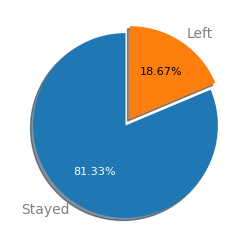

In [ ]:
values = dataset.Left.value_counts()
labels = ['Stayed', 'Left']

fig, ax = plt.subplots(figsize = (4, 3), dpi = 100)
explode = (0, 0.09)

patches, texts, autotexts = ax.pie(values, labels = labels, autopct = '%1.2f%%', shadow = True,
                                    startangle = 90, explode = explode)

plt.setp(texts, color = 'grey')
plt.setp(autotexts, size = 8, color = 'white')
autotexts[1].set_color('black')
plt.show()

### Target balance

The target is imbalanced: **8,133 employees (81.33%) stayed and 1,867 (18.67%) left**. This means a naive model that predicts every employee will stay would already achieve 81.33% accuracy.

The imbalance should therefore be considered when interpreting model performance. Metrics such as precision, recall and the confusion matrix are more informative than accuracy alone. A stratified train/test split or class-weighting strategy would also be worth considering in a subsequent iteration.


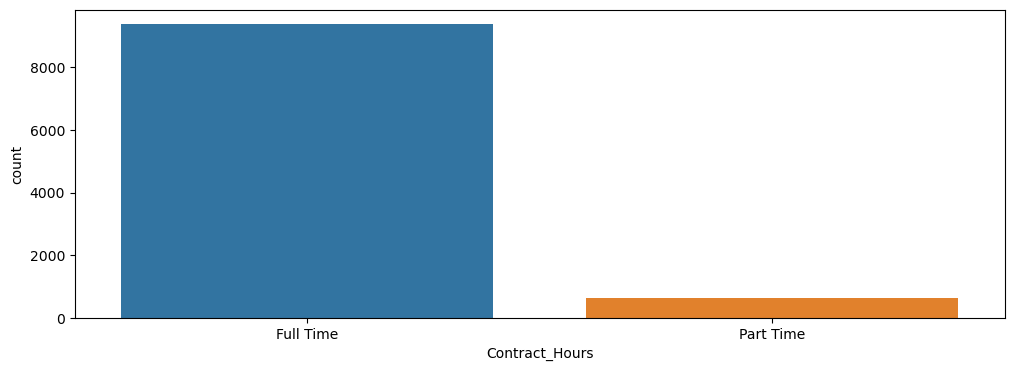

In [ ]:
fig = plt.figure(figsize=(12,4))
sns.countplot(x='Contract_Hours',data=dataset)
plt.show()

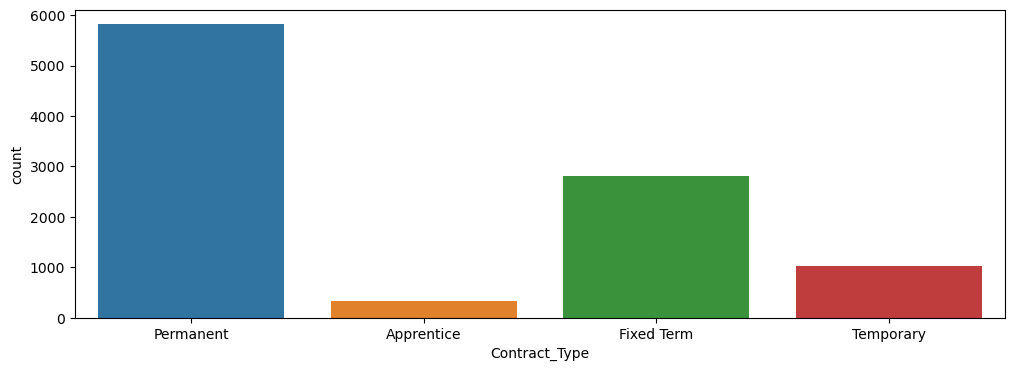

In [ ]:
fig = plt.figure(figsize=(12,4))
sns.countplot(x='Contract_Type',data=dataset)
plt.show()

### Contract profile

The count plots provide context on the composition of the workforce. The dataset contains substantially more full-time and permanent employees than the alternative contract categories. These charts describe the sample structure; they do not, by themselves, show whether contract type is associated with attrition.


In [ ]:
pd.cut(dataset['Satisfaction_Level'], bins=5).value_counts()

(0.6, 0.8]       3012
(0.4, 0.6]       2656
(0.8, 1.0]       2547
(0.2, 0.4]       1031
(-0.001, 0.2]     754
Name: Satisfaction_Level, dtype: int64

In [ ]:
dataset['Satisfaction_Level_bin'] = pd.qcut(dataset['Satisfaction_Level'],
                            q=[0, .2, .4, .6, .8, 1],
                            labels=['Very low', 'Low', 'Moderate', 'High', 'Very high'])
dataset['Satisfaction_Level_bin'].value_counts()

Low          2113
Very low     2022
High         2011
Very high    1968
Moderate     1886
Name: Satisfaction_Level_bin, dtype: int64

<AxesSubplot:xlabel='Satisfaction_Level_bin', ylabel='count'>

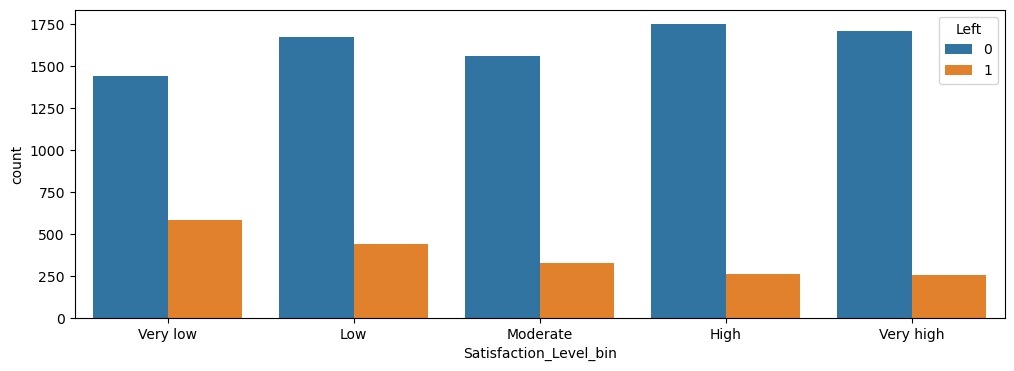

In [ ]:
fig = plt.figure(figsize=(12,4))
sns.countplot(data=dataset, x="Satisfaction_Level_bin", hue="Left")

### Satisfaction level

The distribution suggests that employees with lower satisfaction scores are more frequently represented among those who left. This is an **association in the observed data**, not evidence that low satisfaction alone causes attrition.


In [ ]:
pd.cut(dataset['Last_Year_Evaluation'], bins=5).value_counts()


(0.488, 0.616]    2620
(0.872, 1.0]      2337
(0.744, 0.872]    2280
(0.616, 0.744]    1982
(0.359, 0.488]     781
Name: Last_Year_Evaluation, dtype: int64

In [ ]:
dataset['Last_Year_Evaluation_bin'] = pd.qcut(dataset['Last_Year_Evaluation'],
                            q=[0, .2, .4, .6, .8, 1],
                            labels=['Very low', 'Low', 'Moderate', 'High', 'Very high'])
dataset['Last_Year_Evaluation_bin'].value_counts()

Very low     2072
Moderate     2019
Very high    1993
High         1975
Low          1941
Name: Last_Year_Evaluation_bin, dtype: int64

<AxesSubplot:xlabel='Last_Year_Evaluation_bin', ylabel='count'>

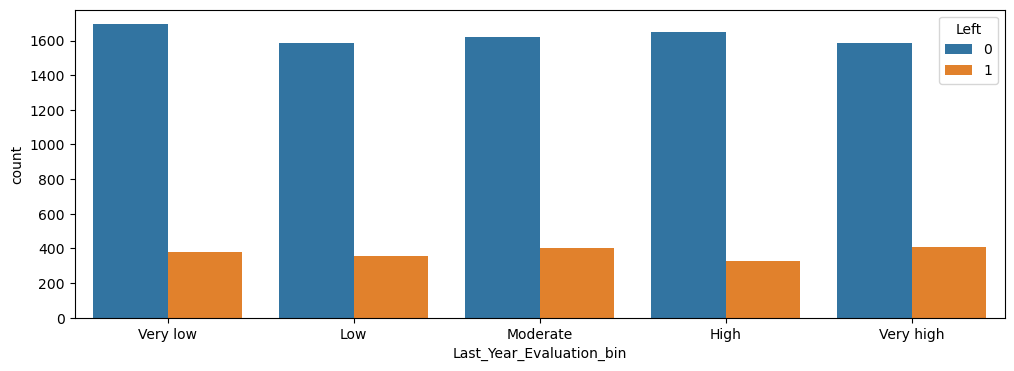

In [ ]:
fig = plt.figure(figsize=(12,4))
sns.countplot(data=dataset, x="Last_Year_Evaluation_bin", hue="Left")

### Previous-year evaluation

The distributions for `Last_Year_Evaluation` overlap considerably between employees who stayed and those who left. On this visual evidence, the feature does not appear to separate the two groups strongly on its own.


In [ ]:
pd.cut(dataset['Environment_Satisfaction'], bins=5).value_counts()

(0.264, 0.448]     3352
(0.0791, 0.264]    2289
(0.448, 0.632]     1760
(0.816, 1.0]       1394
(0.632, 0.816]     1205
Name: Environment_Satisfaction, dtype: int64

In [ ]:
dataset['Environment_Satisfaction_bin'] = pd.qcut(dataset['Environment_Satisfaction'],
                            q=[0, .2, .4, .6, .8, 1],
                            labels=['Very low', 'Low', 'Moderate', 'High', 'Very high'])
dataset['Environment_Satisfaction_bin'].value_counts()

Very low     2289
Low          2267
Very high    1952
High         1943
Moderate     1549
Name: Environment_Satisfaction_bin, dtype: int64

<AxesSubplot:xlabel='Environment_Satisfaction_bin', ylabel='count'>

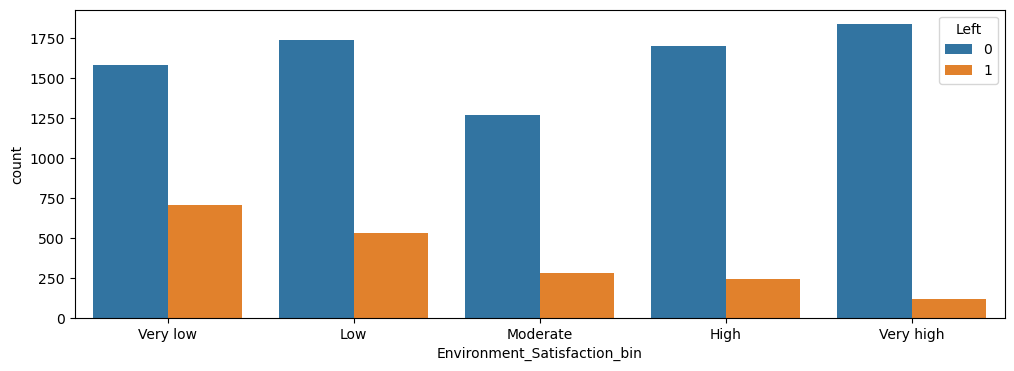

In [ ]:
fig = plt.figure(figsize=(12,4))
sns.countplot(data=dataset, x="Environment_Satisfaction_bin", hue="Left")

### Environment satisfaction

Lower environment-satisfaction scores appear more common among employees who left. This suggests that workplace environment may be associated with attrition, although the chart alone cannot establish causality or control for the influence of other variables.


In [ ]:
pd.cut(dataset['Salary'], bins=4).value_counts()


(20951.933, 40408.663]    6767
(40408.663, 59787.875]    1814
(59787.875, 79167.088]    1415
(79167.088, 98546.3]         4
Name: Salary, dtype: int64

In [ ]:
bins = np.linspace(min(dataset['Salary']), max(dataset['Salary']),4)
groupNames = ["low", "med", "high"]
dataset['SalGroup'] = pd.cut(dataset['Salary'], bins, labels = groupNames, include_lowest = True)


In [ ]:
dataset.SalGroup.value_counts()

low     7685
med     2294
high      21
Name: SalGroup, dtype: int64

<AxesSubplot:xlabel='SalGroup', ylabel='count'>

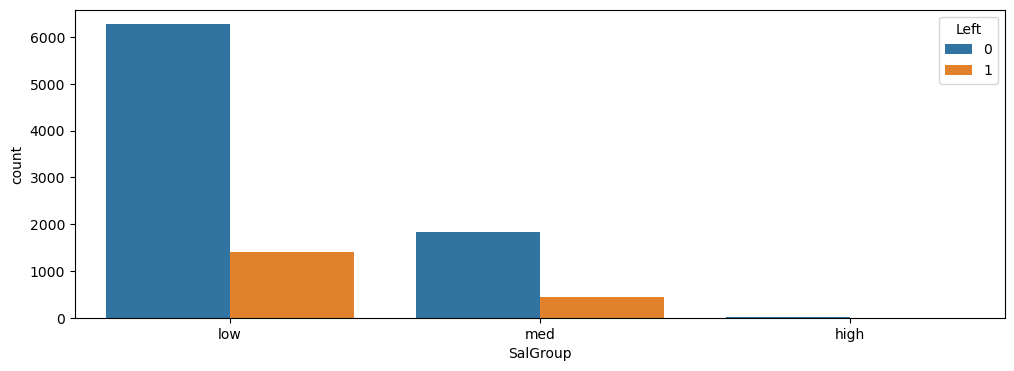

In [ ]:
fig = plt.figure(figsize=(12,4))
sns.countplot(data=dataset, x="SalGroup", hue="Left")

### Salary

The salary groups show differences in the number of employees who stayed and left. However, the groups are highly uneven in size, particularly the highest salary band, so the count plot is not sufficient to conclude that salary is a major cause of attrition. Attrition *rates* within comparable salary bands would provide a stronger basis for interpretation.


In [ ]:
pd.cut(dataset['Work_Life_Balance'], bins=5).value_counts()

(2.8, 3.4]      2981
(3.4, 4.0]      2596
(1.6, 2.2]      2464
(0.997, 1.6]    1959
(2.2, 2.8]         0
Name: Work_Life_Balance, dtype: int64

In [ ]:
bins = np.linspace(min(dataset['Work_Life_Balance']), max(dataset['Work_Life_Balance']),5)
groupNames = ["poor", "fair", "better","excellent"]
dataset['Work_Life_Balance_Group'] = pd.cut(dataset['Work_Life_Balance'], bins, labels = groupNames, include_lowest = True)


In [ ]:
dataset.Work_Life_Balance_Group.value_counts()

better       2981
excellent    2596
fair         2464
poor         1959
Name: Work_Life_Balance_Group, dtype: int64

<AxesSubplot:xlabel='Work_Life_Balance_Group', ylabel='count'>

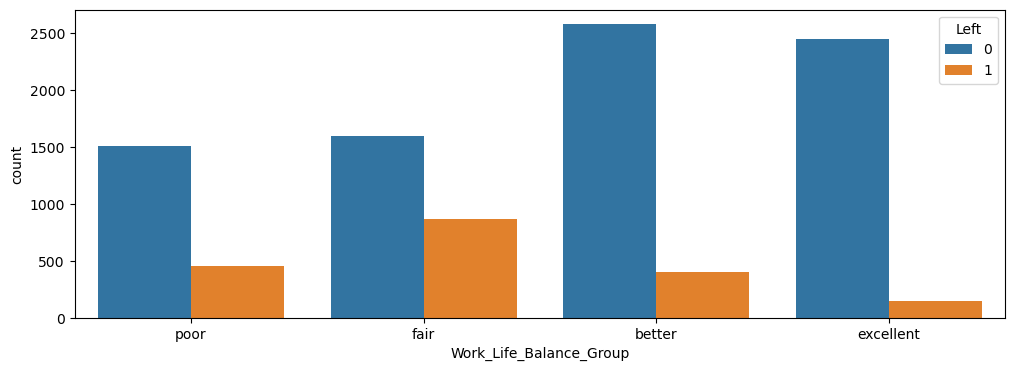

In [ ]:
fig = plt.figure(figsize=(12,4))
sns.countplot(data=dataset, x="Work_Life_Balance_Group", hue="Left")

### Work-life balance

Employees reporting stronger work-life balance appear less represented among leavers than employees in the lower categories. This pattern suggests an association between work-life balance and retention, but it should be considered alongside the other employee and role characteristics.


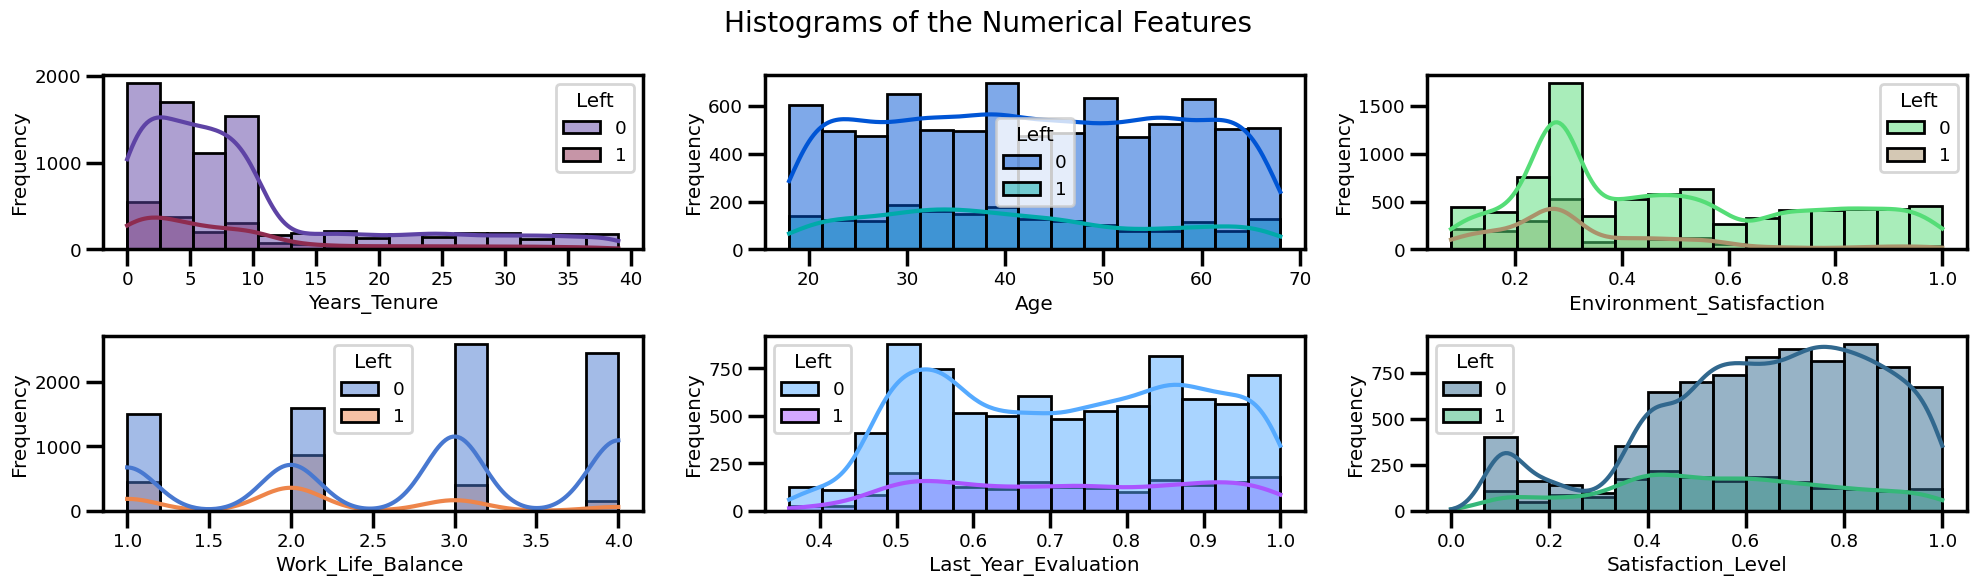

In [ ]:
sns.set_context('poster', font_scale= 0.6)
fig, ax  = plt.subplots(2, 3, figsize=(20, 6))

plt.suptitle('Histograms of the Numerical Features', fontsize = 20)

ax1 = sns.histplot(x = dataset['Years_Tenure'],color= 'teal', hue= dataset['Left'], ax= ax[0][0], bins= 15, kde= True, palette= 'twilight')
ax1.set(xlabel= 'Years_Tenure', ylabel= 'Frequency')

ax2 = sns.histplot(x = dataset['Age'], color= 'teal', hue= dataset['Left'], ax= ax[0][1], bins= 15, kde= True, palette= 'winter')
ax2.set(xlabel= 'Age', ylabel= 'Frequency')

ax3 = sns.histplot(x = dataset['Environment_Satisfaction'], color= 'teal', hue= dataset['Left'], ax= ax[0][2], bins= 15, kde= True, palette= 'terrain')
ax3.set(xlabel= 'Environment_Satisfaction', ylabel= 'Frequency')

ax4 = sns.histplot(x = dataset['Work_Life_Balance'],color= 'teal', hue= dataset['Left'], ax= ax[1][0], bins= 15, kde= True, palette= 'muted')
ax4.set(xlabel= 'Work_Life_Balance ', ylabel= 'Frequency')

ax5 = sns.histplot(x = dataset['Last_Year_Evaluation'], color= 'teal', hue= dataset['Left'], ax= ax[1][1], bins= 15, kde= True, palette= 'cool')
ax5.set(xlabel= 'Last_Year_Evaluation', ylabel= 'Frequency')

ax6 = sns.histplot(x = dataset['Satisfaction_Level'], color= 'teal', hue= dataset['Left'], ax= ax[1][2], bins= 15, kde= True, palette= 'viridis')
ax6.set(xlabel= 'Satisfaction_Level', ylabel= 'Frequency')



plt.tight_layout()
plt.show()

### Numerical feature distributions by attrition

The histograms compare the distributions of tenure, age, environment satisfaction, work-life balance, previous-year evaluation and overall satisfaction for employees who stayed and left.

One visible pattern is that leavers are concentrated more heavily among employees with shorter tenure. The remaining features show varying degrees of overlap, reinforcing the need to evaluate several variables together rather than treat any single measure as a complete explanation of attrition.


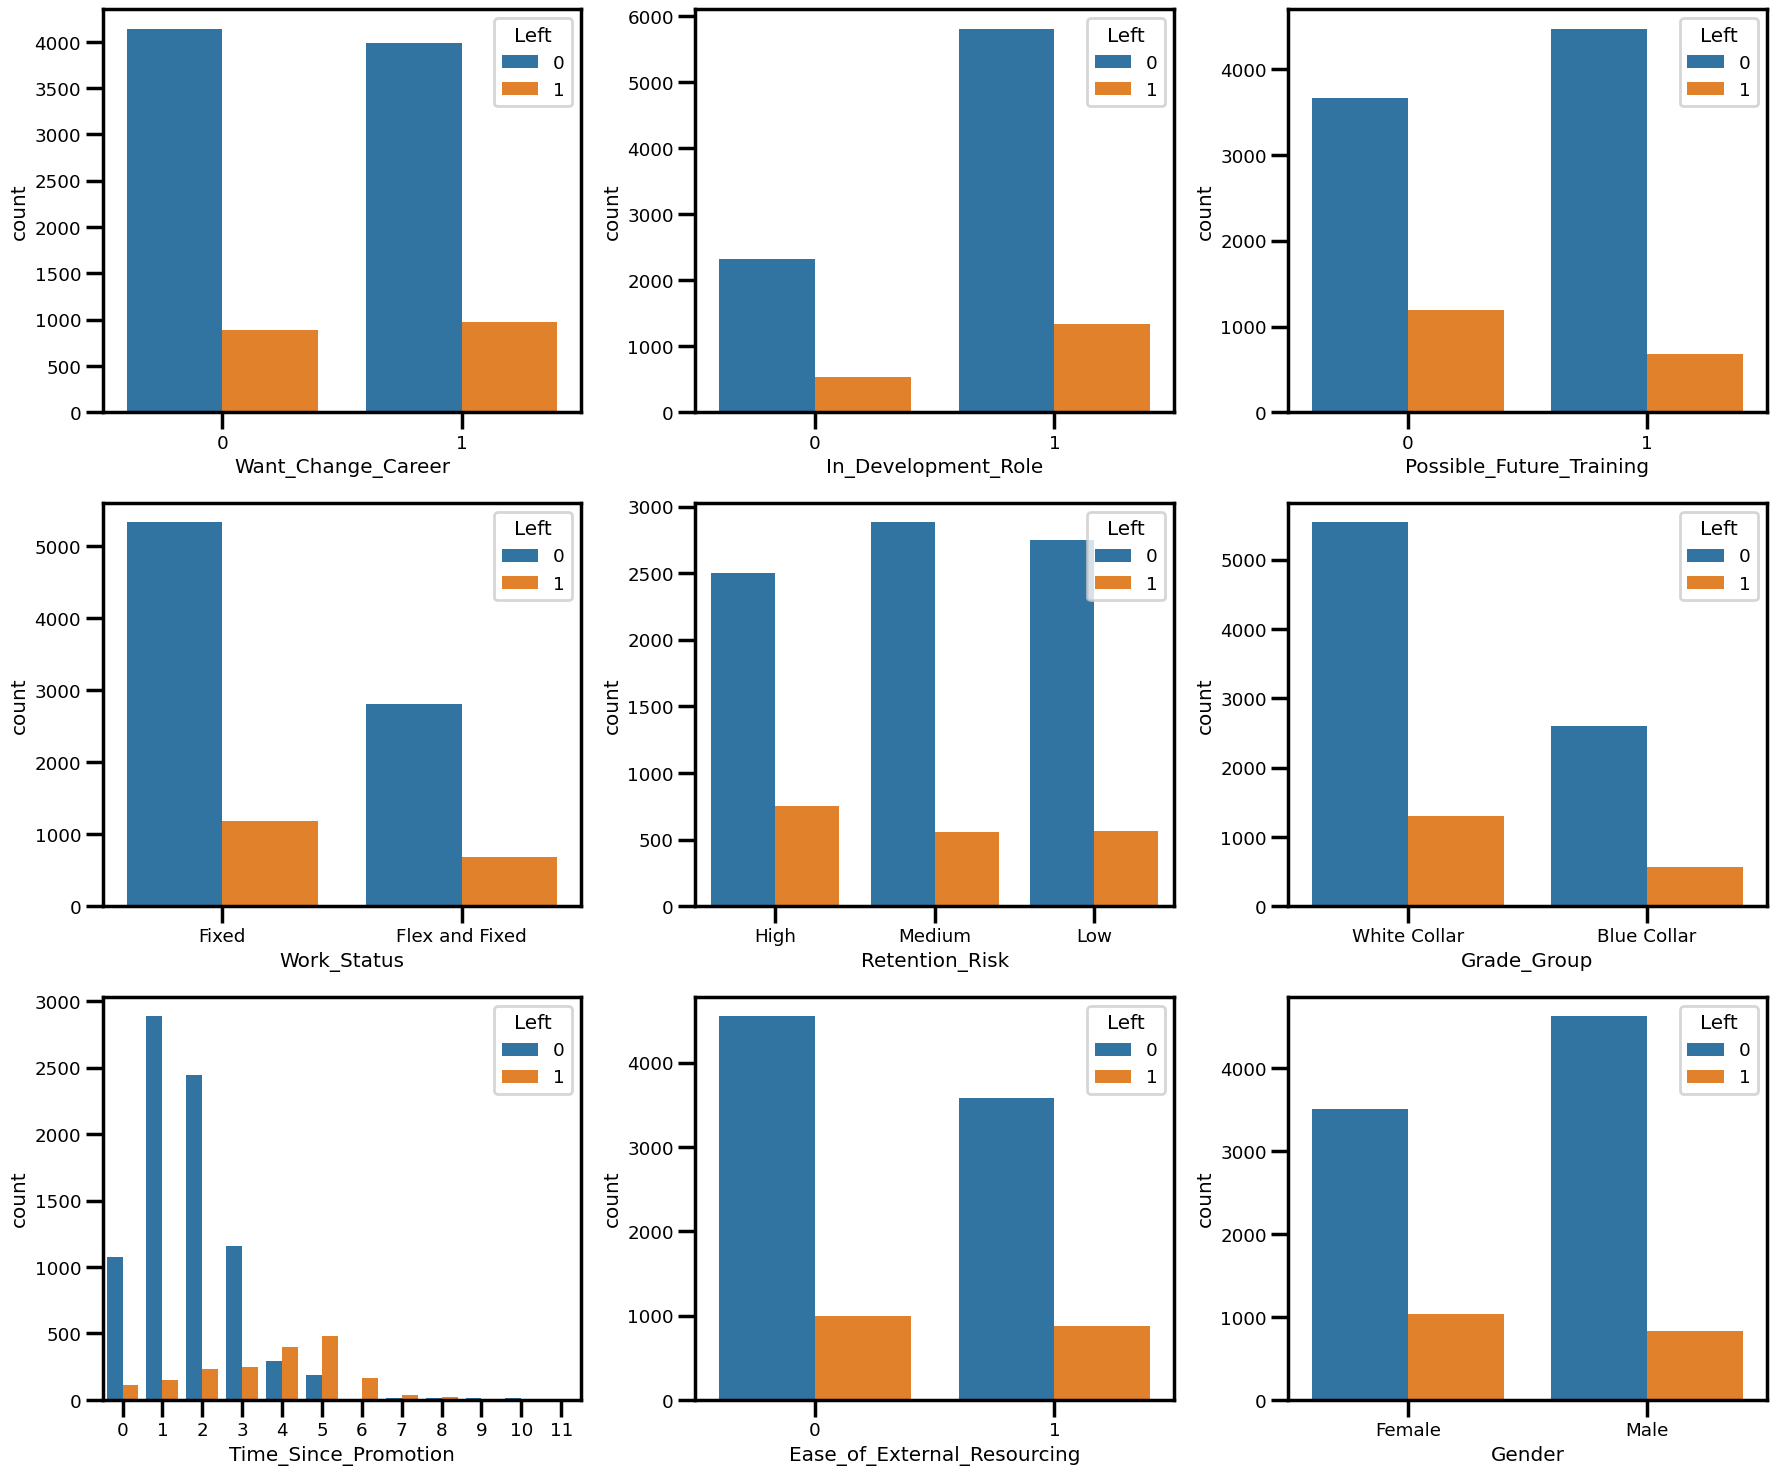

In [ ]:
# visualizing categorical variables

fig, ax = plt.subplots(3, 3, figsize = (18, 15))

sns.countplot('Want_Change_Career', hue = 'Left', data = dataset, ax = ax[0][0])
sns.countplot('In_Development_Role', hue = 'Left', data = dataset, ax = ax[0][1])
sns.countplot('Possible_Future_Training', hue = 'Left', data = dataset, ax = ax[0][2])
sns.countplot('Work_Status', hue = 'Left', data = dataset, ax = ax[1][0])
sns.countplot('Retention_Risk', hue = 'Left', data = dataset, ax = ax[1][1])
sns.countplot('Grade_Group', hue = 'Left', data = dataset, ax = ax[1][2])
sns.countplot('Time_Since_Promotion', hue = 'Left', data = dataset, ax = ax[2][0])
sns.countplot('Ease_of_External_Resourcing', hue = 'Left', data = dataset, ax = ax[2][1])
sns.countplot('Gender', hue = 'Left', data = dataset, ax = ax[2][2])


plt.tight_layout()
plt.show()

### Categorical features by attrition

The categorical plots compare attrition across career intentions, development opportunities, training, work status, retention-risk rating, grade group, time since promotion, ease of external resourcing and gender.

Several variables show visibly different distributions between employees who stayed and those who left, particularly development- and retention-related measures. These plots are useful for identifying candidate relationships for further analysis, but raw counts can be affected by the size of each category. For stronger conclusions, the next iteration should calculate attrition **rates** for each group and, where appropriate, test whether the observed differences are statistically meaningful.

The gender plot also highlights the importance of fairness checks. If gender is retained as a model feature, subgroup performance and potential discriminatory effects should be assessed before any real-world use.


Taken together, the exploratory plots suggest that attrition is associated with a combination of satisfaction, tenure, work-life balance, development and other employment-related factors. The analysis does not establish that these variables cause employees to leave, and several relationships may overlap or interact with one another.


### Comparing numerical features by attrition

Boxplots provide another view of the numerical variables by comparing their medians, spread and potential outliers for employees who stayed and those who left. They are useful for identifying distributional differences that may be less obvious in the earlier count plots and histograms.


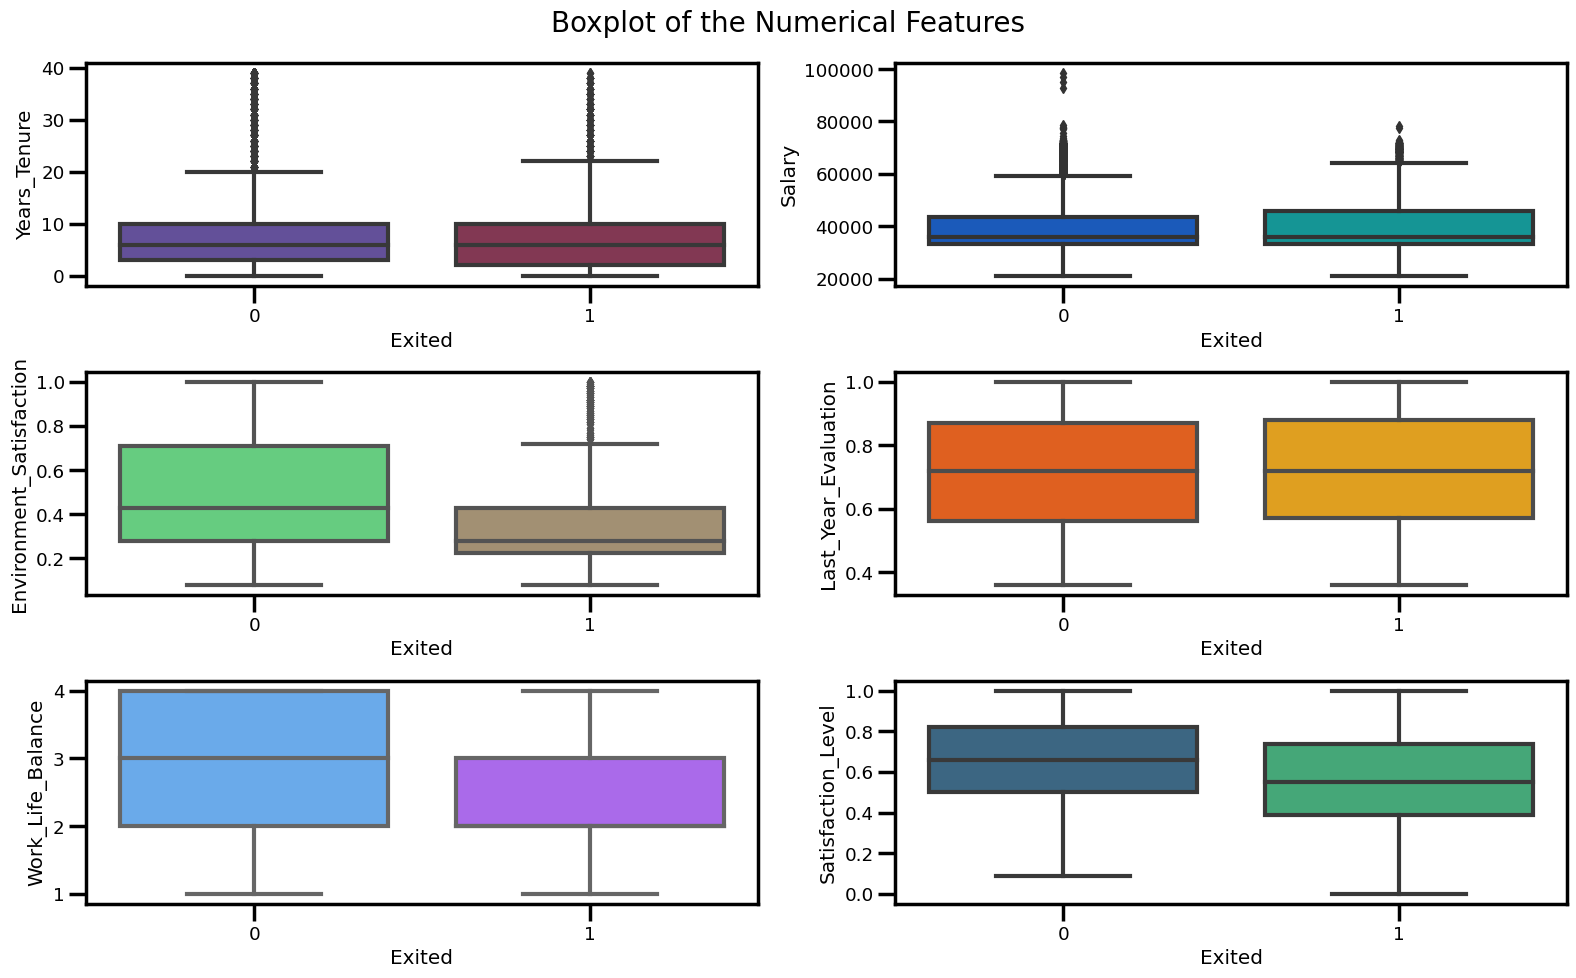

In [ ]:
sns.set_context('poster', font_scale= 0.6)
fig, ax  = plt.subplots(3, 2, figsize=(16, 10))

plt.suptitle('Boxplot of the Numerical Features', fontsize = 20)

ax1 = sns.boxplot(y = dataset['Years_Tenure'], x= dataset['Left'], ax= ax[0][0], palette= 'twilight')
ax1.set(xlabel= 'Exited', ylabel= 'Years_Tenure')

ax2 = sns.boxplot(y = dataset['Salary'], x= dataset['Left'], ax= ax[0][1], palette= 'winter')
ax2.set(xlabel= 'Exited', ylabel= 'Salary')

ax3 = sns.boxplot(y = dataset['Environment_Satisfaction'], x= dataset['Left'], ax= ax[1][0], palette= 'terrain')
ax3.set(xlabel= 'Exited', ylabel= 'Environment_Satisfaction')

ax4 = sns.boxplot(y = dataset['Last_Year_Evaluation'], x= dataset['Left'], ax= ax[1][1], palette= 'autumn')
ax4.set(xlabel= 'Exited', ylabel= 'Last_Year_Evaluation')

ax5 = sns.boxplot(y = dataset['Work_Life_Balance'], x= dataset['Left'], ax= ax[2][0], palette= 'cool')
ax5.set(xlabel= 'Exited', ylabel= 'Work_Life_Balance')

ax6 = sns.boxplot(y = dataset['Satisfaction_Level'], x= dataset['Left'], ax= ax[2][1], palette= 'viridis')
ax6.set(xlabel= 'Exited', ylabel= 'Satisfaction_Level')

plt.tight_layout()
plt.show()

### Correlation between numerical features

The correlation heatmap summarises pairwise linear relationships between numerical variables. It can help identify features that move together and indicate whether any single numerical feature has a strong linear association with `Left`.

Correlation should not be interpreted as causation, and a weak linear correlation does not mean a variable has no predictive value: non-linear relationships and interactions may still exist.


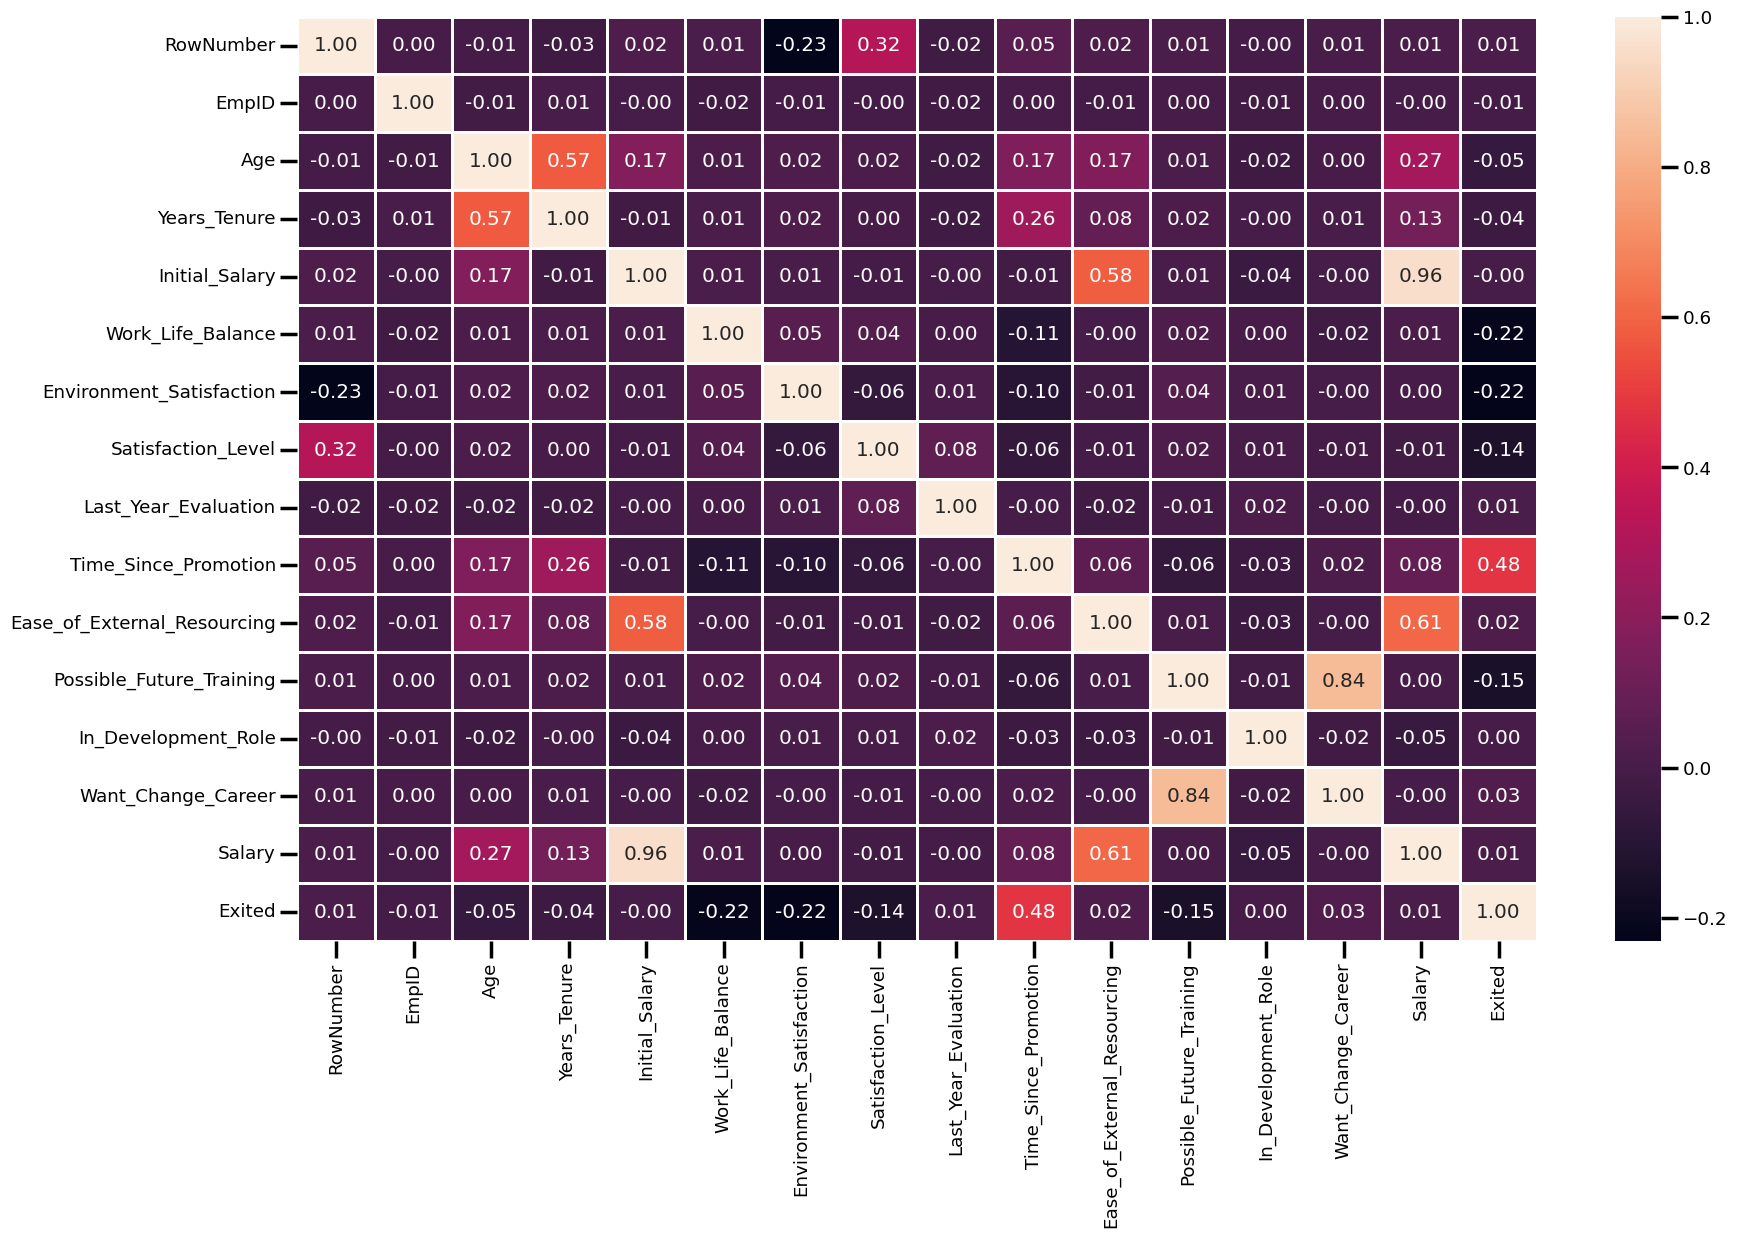

In [ ]:
# heatmap

plt.figure(figsize = (20, 12))

corr = dataset.corr()

sns.heatmap(corr, linewidths = 1, annot = True, fmt = ".2f")
plt.show()

### Removing identifiers, post-outcome fields and helper columns

Before modelling, the analysis removes identifiers and administrative fields that are not appropriate predictors, including row numbers, employee IDs, surnames and exact dates. `Leaving_Date` is excluded because it would only be known after the outcome and would therefore introduce target leakage.

The temporary binned variables created for exploratory visualisation are also removed. The remaining columns form the candidate feature set used to train the model.


In [ ]:
# dropping unecessary columns

dataset.drop(columns =['RowNumber','EmpID','Surname','Birthday_Date','Start_Date','Leaving_Date','Position',
                       'Employment_Status','Tenure','Contract_Type','Contract_Hours','Satisfaction_Level_bin',
                      'Last_Year_Evaluation_bin',  'Environment_Satisfaction_bin','SalGroup','Work_Life_Balance_Group'], inplace=True, axis=1)
dataset.head()


,Grade_Group,Work_Status,Retention_Risk,Gender,Age,Years_Tenure,Initial_Salary,Work_Life_Balance,Environment_Satisfaction,Satisfaction_Level,Last_Year_Evaluation,Time_Since_Promotion,Ease_of_External_Resourcing,Possible_Future_Training,In_Development_Role,Want_Change_Career,Salary,Left
0,White Collar,Fixed,High,Female,65,9,30894.000,1,0.35,0.38,0.53,5,1,1,1,1,33949.45,1
1,Blue Collar,Fixed,Medium,Female,19,0,21711.550,2,0.96,0.80,0.86,0,0,1,1,1,21711.55,0
2,White Collar,Flex and Fixed,Low,Female,66,13,35500.600,4,0.45,0.11,0.88,5,1,0,1,1,44375.75,1
3,White Collar,Fixed,High,Female,58,22,36935.888,4,0.46,0.72,0.87,2,0,0,0,0,41972.60,0
4,Blue Collar,Fixed,Medium,Female,64,15,27386.190,3,0.45,0.37,0.52,4,0,1,1,0,35110.50,0


### Preparing the feature matrix and target

The remaining predictor columns are separated into `X`, while `Left` is assigned to `y` as the binary target.


In [ ]:
X = dataset.iloc[:, :-1].values
y = dataset.iloc[:, -1].values

In [ ]:
print(X)

[['White Collar' 'Fixed' 'High' ... 1 1 33949.45]
 ['Blue Collar' 'Fixed' 'Medium' ... 1 1 21711.55]
 ['White Collar' 'Flex and Fixed' 'Low' ... 1 1 44375.75]
 ...
 ['White Collar' 'Fixed' 'Medium' ... 0 1 32200.1]
 ['White Collar' 'Fixed' 'Medium' ... 1 0 32265.25]
 ['Blue Collar' 'Fixed' 'Low' ... 1 0 36622.1]]


In [ ]:
print(y)

[1 0 1 ... 1 1 0]


### Encoding binary categorical variables

`Grade_Group`, `Work_Status` and `Gender` are converted from text categories to numerical values using label encoding. Each of these variables has two categories, so a binary numerical representation is sufficient for the model input.


In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
X[:, 0] = le.fit_transform(X[:, 0])
X[:, 1] = le.fit_transform(X[:, 1])
X[:, 3] = le.fit_transform(X[:, 3])

In [ ]:
print(X)

[[1 0 'High' ... 1 1 33949.45]
 [0 0 'Medium' ... 1 1 21711.55]
 [1 1 'Low' ... 1 1 44375.75]
 ...
 [1 0 'Medium' ... 0 1 32200.1]
 [1 0 'Medium' ... 1 0 32265.25]
 [0 0 'Low' ... 1 0 36622.1]]


### One-hot encoding `Retention_Risk`

`Retention_Risk` contains three categories, so it is one-hot encoded rather than represented as a single integer. This avoids imposing an arbitrary numerical distance between the category labels.

For real-world deployment, it would also be important to confirm that `Retention_Risk` is recorded **before** the employee outcome being predicted; otherwise it could introduce temporal leakage.


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
ct = ColumnTransformer(transformers=[('encoder', OneHotEncoder(), [2])], remainder='passthrough')
X = np.array(ct.fit_transform(X))

In [ ]:
print(X)

[[1.0 0.0 0.0 ... 1 1 33949.45]
 [0.0 0.0 1.0 ... 1 1 21711.55]
 [0.0 1.0 0.0 ... 1 1 44375.75]
 ...
 [0.0 0.0 1.0 ... 0 1 32200.1]
 [0.0 0.0 1.0 ... 1 0 32265.25]
 [0.0 1.0 0.0 ... 1 0 36622.1]]


### Splitting the data into training and test sets

The data is divided into an 80% training set and a 20% test set using a fixed random seed (`random_state=0`) for reproducibility. The test set is held back from model fitting and used to estimate performance on unseen records.

Because the target is imbalanced, a future refinement would be to use `stratify=y` so that the proportion of leavers is explicitly preserved in both subsets.


In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)

### Feature scaling

The features are standardised using `StandardScaler`. The scaler is fitted on the training data only and then applied to the test data, which avoids using information from the test set during preprocessing.

Scaling is particularly important for neural networks because gradient-based optimisation is sensitive to large differences in feature magnitude. Without scaling, variables such as salary could influence optimisation disproportionately simply because they use a larger numerical scale.


In [ ]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

## Part 2 — Building the Artificial Neural Network

An Artificial Neural Network is used here to explore whether a non-linear model can learn useful combinations and interactions across the selected employee features.

The exploratory correlation analysis does **not** by itself prove that an ANN is the best model. A robust model-selection process would compare this network against simpler baselines such as logistic regression and tree-based models using the same held-out data or cross-validation. The ANN should therefore be viewed as one candidate model rather than an automatically superior choice.


### Initialising the network

A Keras `Sequential` model is used so that the layers can be added in order from the input representation to the final binary prediction.


In [ ]:
ann = tf.keras.models.Sequential()

### First hidden layer

The first hidden layer contains six units with a ReLU activation function. ReLU allows the network to learn non-linear relationships while keeping the architecture relatively small for this proof of concept.

The choice of six units is a modelling choice rather than an empirically proven optimum; alternative architectures could be evaluated through systematic tuning.


In [ ]:
ann.add(tf.keras.layers.Dense(units=6, activation='relu'))

### Second hidden layer

A second hidden layer with six ReLU units adds further capacity to combine patterns learned by the first layer. As with the first layer, the architecture is intentionally compact but has not been exhaustively tuned.


In [ ]:
ann.add(tf.keras.layers.Dense(units=6, activation='relu'))

### Output layer

The output layer contains one unit with a sigmoid activation function. This produces a value between 0 and 1 that can be interpreted as the model's estimated probability for the positive class (`Left = 1`). A threshold of 0.5 is later used to convert that probability into a binary prediction.


In [ ]:
ann.add(tf.keras.layers.Dense(units=1, activation='sigmoid'))

## Part 3 — Training the ANN

The network is compiled and trained on the scaled training data. Training performance is monitored across epochs before the final model is evaluated on the held-out test set.


### Compiling the ANN

The model uses the Adam optimiser and binary cross-entropy loss, a standard combination for binary neural-network classification. Accuracy is tracked during training, although the class imbalance means that accuracy alone is not sufficient to judge model quality.


In [ ]:
ann.compile(optimizer = 'adam', loss = 'binary_crossentropy', metrics = ['accuracy'])

### Training the ANN

The model is trained for 100 epochs with a batch size of 32. Training accuracy rises to approximately 91% by the later epochs and the training loss becomes relatively stable.

However, no validation set or validation-loss curve is used during training, so the training history alone cannot confirm that 100 epochs is optimal or that overfitting has not occurred. A stronger implementation would use a validation split together with early stopping and would retain the best-performing model based on validation performance.


In [ ]:
ann.fit(X_train, y_train, batch_size = 32, epochs = 100)

Epoch 1/100
250/250 [==============================] - 1s 2ms/step - loss: 0.5534 - accuracy: 0.7384
Epoch 2/100
250/250 [==============================] - 0s 2ms/step - loss: 0.3930 - accuracy: 0.8353
Epoch 3/100
250/250 [==============================] - 0s 2ms/step - loss: 0.3315 - accuracy: 0.8696
Epoch 4/100
250/250 [==============================] - 0s 1ms/step - loss: 0.3049 - accuracy: 0.8851
Epoch 5/100
250/250 [==============================] - 0s 1ms/step - loss: 0.2939 - accuracy: 0.8923
Epoch 6/100
250/250 [==============================] - 0s 1ms/step - loss: 0.2880 - accuracy: 0.8944
Epoch 7/100
250/250 [==============================] - 0s 1ms/step - loss: 0.2837 - accuracy: 0.8950
Epoch 8/100
250/250 [==============================] - 0s 1ms/step - loss: 0.2809 - accuracy: 0.8961
Epoch 9/100
250/250 [==============================] - 0s 1ms/step - loss: 0.2781 - accuracy: 0.8980
Epoch 10/100
250/250 [==============================] - 0s 1ms/step - loss: 0.2760 - accura

## Part 4 — Prediction and model evaluation

The trained network is used first to demonstrate single-record scoring and then to generate predictions for the held-out test set. Performance is assessed using the confusion matrix and classification metrics derived from it.


### Illustrative single-record prediction

The following cell demonstrates how a single observation can be passed through the fitted scaler and ANN to produce a binary prediction.


The single-record example is intended as a technical demonstration of inference rather than a business conclusion about an individual employee.

Because the preprocessing steps transform categorical variables and change the feature representation, manually constructing a positional input vector is error-prone. A production-quality implementation should combine preprocessing and prediction into a single reproducible pipeline and accept named raw fields, ensuring that every value is mapped to the correct feature and category before scoring.


**Illustrative model output**


In [ ]:
print(ann.predict(sc.transform([[0,1,0,1,1,65, 9,1,0.35,0.38,0.53,5,30894, 1,1,1,1, 33949.45,1]])) > 0.5)

1/1 [==============================] - 0s 124ms/step
[[ True]]


In [ ]:
y_pred = ann.predict(X_test)
y_pred = (y_pred > 0.5)
print(np.concatenate((y_pred.reshape(len(y_pred),1), y_test.reshape(len(y_test),1)),1))

63/63 [==============================] - 0s 1ms/step
[[0 0]
 [1 1]
 [0 0]
 ...
 [0 0]
 [0 0]
 [0 0]]


### Predicting the test-set outcomes

The ANN generates a probability for each of the 2,000 held-out records. Probabilities above 0.5 are classified as `Left = 1`; the resulting predictions are then compared with the observed outcomes.


In [ ]:
y_pred = ann.predict(X_test)
y_pred = (y_pred > 0.5)
print(np.concatenate((y_pred.reshape(len(y_pred),1), y_test.reshape(len(y_test),1)),1))

63/63 [==============================] - 0s 1ms/step
[[0 0]
 [1 1]
 [0 0]
 ...
 [0 0]
 [0 0]
 [0 0]]


### Confusion matrix and accuracy

The confusion matrix shows how the model's 2,000 test-set predictions compare with the observed outcomes. This makes the types of errors visible rather than relying on overall accuracy alone.


In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score
cm = confusion_matrix(y_test, y_pred)
print(cm)
accuracy_score(y_test, y_pred)

[[1574   50]
 [ 126  250]]


0.912

## Results and interpretation

On the 2,000 held-out employees, the confusion matrix is:

| | Predicted: stay | Predicted: leave |
|---|---:|---:|
| **Actually stayed** | 1,574 | 50 |
| **Actually left** | 126 | 250 |

From these results:

- **Accuracy: 91.2%** — higher than the 81.2% majority-class baseline on this test set (1,624 of 2,000 employees stayed).
- **Precision for leavers: 83.3%** — of the 300 employees predicted to leave, 250 actually left.
- **Recall for leavers: 66.5%** — the model identified 250 of the 376 employees who actually left.
- **False negatives: 126** — these are employees who left but were predicted to stay.
- **False positives: 50** — these are employees predicted to leave who actually stayed.

The results show that the ANN adds predictive signal beyond the majority-class baseline, but the 66.5% recall also means that roughly one-third of actual leavers in the test set were missed. Whether this is acceptable depends on the relative cost of false positives and false negatives in the intended HR process.

The model should therefore be treated as an **early proof of concept**, not as a finished employee-retention decision system. It can help demonstrate how employee data might support earlier investigation, but any intervention should remain human-led and should consider the broader context behind an individual prediction.

### Limitations and next steps

- **Class imbalance:** only 18.67% of employees left. Future experiments should compare class weighting, resampling and threshold tuning, with recall, precision, F1 and PR-AUC reported alongside accuracy.
- **Model comparison:** the ANN has not been benchmarked here against simpler models such as logistic regression or tree-based classifiers. A consistent cross-validation framework would show whether the additional complexity provides a genuine benefit.
- **Validation strategy:** the model is trained for a fixed 100 epochs without a validation set or early stopping. Adding both would provide better control of overfitting and model selection.
- **Temporal validity:** every predictor must be confirmed as available before the employee left. This is especially important for variables such as `Retention_Risk`, which could otherwise leak information about the outcome.
- **Single-record scoring:** the manual positional vector used in the demonstration is fragile. Preprocessing and inference should be wrapped in one pipeline so raw named inputs are transformed consistently.
- **Fairness and governance:** sensitive or protected characteristics, including gender, require careful justification, subgroup performance testing and appropriate HR/legal governance before deployment.
- **Interpretability:** the exploratory analysis suggests several useful associations, but a neural network does not directly establish why a prediction was made. Feature-attribution techniques and comparison with interpretable baselines would improve transparency.

Overall, the notebook demonstrates an end-to-end classification workflow and produces promising test-set accuracy, while also identifying clear areas that would need to be strengthened before the model could be considered for operational use.
